In [60]:
import h5py
import numpy as np
import pandas as pd
import random
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import corner

from scipy import stats
from astroML.utils import completeness_contamination
from astroML.classification import GMMBayes

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    precision_score, 
    roc_curve, 
    roc_auc_score, 
    auc, 
    confusion_matrix, 
    precision_score, 
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report

Can a computern learn if we're going to detect a GW?

In [61]:
with h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as file:
    
    keys = list(file.keys())
    print(keys)
    
    data = {}
    for key in keys:
        data[key] = file[key][:]

total_samples = len(data['det'])
print (f"Total samples:{total_samples}")

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']
Total samples:20000000


In [ ]:
# Possibility to do downsampling
N_samples = total_samples // 1

idx = np.random.choice(total_samples, N_samples, replace=False)

par_keys = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'ra', 'iota', 'psi', 'z'] # remove snr
lab_keys = ['det']

# Create X and y to perform split
X = np.stack([data[k][idx] for k in par_keys], axis=1)
y = data['det'][idx].astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=52)

X_train.shape, y_train.shape, X_test.shape, y_test.shape


print (f"number of detectable samples in the training (1): {np.sum(y_train==1)}")
print (f"number of non-detectable samples in the training (0): {np.sum(y_train==0)}")



number of detectable samples in the training (1): 201704
number of non-detectable samples in the training (0): 1198296


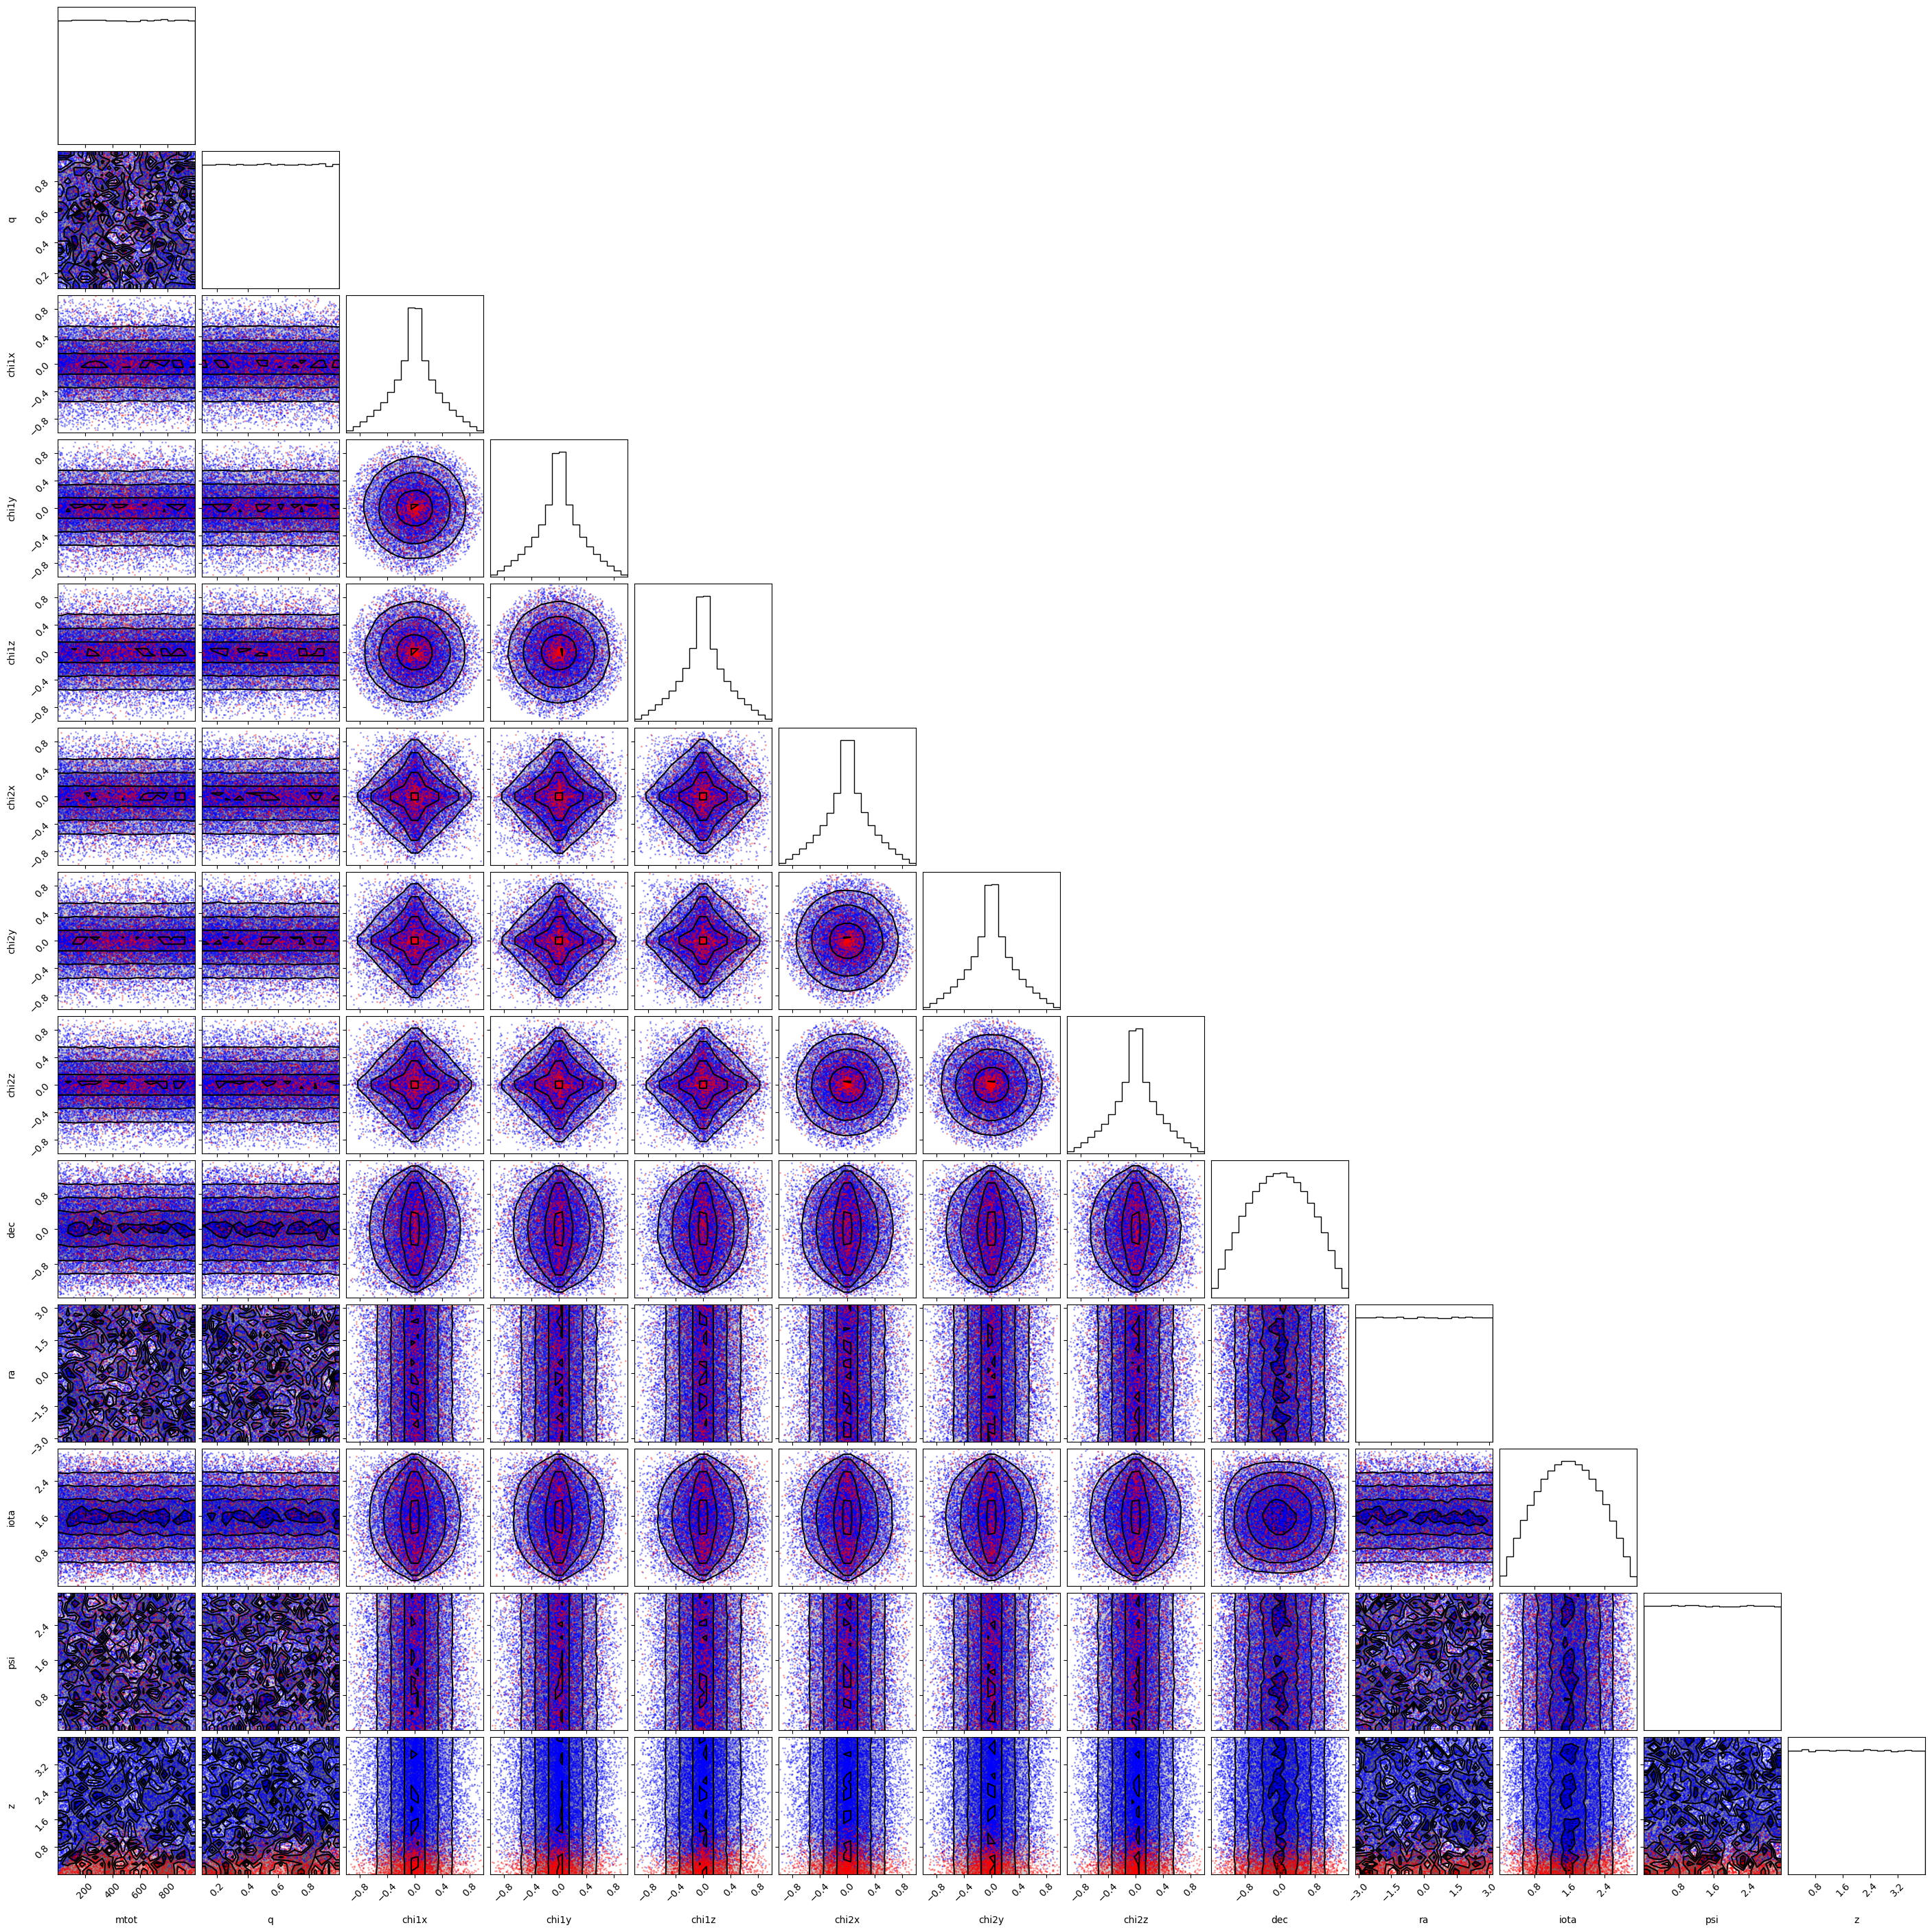

In [63]:
# Corner plot of all training data

figure = corner.corner(X_train, labels=par_keys, plot_datapoints=False, plot_density=False, fill_contours=True)
axes = np.array(figure.axes).reshape(len(par_keys), len(par_keys))

# Do again a downsampling (only for the plot)
n_plot = min(len(X_train), X_train.shape[0] //100)
plot_idx = np.random.choice(len(X_train), n_plot, replace=False)
X_plot = X_train[plot_idx]
y_plot = y_train[plot_idx]

for i in range(len(par_keys)):
    for j in range(i):
        ax = axes[i, j]
    
        ax.scatter(X_plot[y_plot == 0, j], X_plot[y_plot == 0, i], 
                   color="blue", s=1, alpha=0.3, label="Not Det" if i==1 and j==0 else "")
        ax.scatter(X_plot[y_plot == 1, j], X_plot[y_plot == 1, i], 
                   color="red", s=1, alpha=0.3, label="Det" if i==1 and j==0 else "")

plt.show()

In [64]:
# Print the correlation matrix (using Pearson coeff.)
df_train = pd.DataFrame(X_train, columns=par_keys)
corr_matrix = df_train.corr()
print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
           mtot         q     chi1x     chi1y     chi1z     chi2x     chi2y  \
mtot   1.000000  0.000404 -0.000384  0.000570 -0.000420  0.001287  0.002093   
q      0.000404  1.000000 -0.000445 -0.000632 -0.000132  0.000902 -0.000939   
chi1x -0.000384 -0.000445  1.000000 -0.000393 -0.000125  0.000811  0.001724   
chi1y  0.000570 -0.000632 -0.000393  1.000000 -0.000370 -0.000288  0.000127   
chi1z -0.000420 -0.000132 -0.000125 -0.000370  1.000000  0.000329  0.000451   
chi2x  0.001287  0.000902  0.000811 -0.000288  0.000329  1.000000 -0.000245   
chi2y  0.002093 -0.000939  0.001724  0.000127  0.000451 -0.000245  1.000000   
chi2z  0.000922  0.001309 -0.000781  0.000668  0.000717  0.000432 -0.000525   
dec    0.001842 -0.000138  0.000659 -0.000301  0.000451 -0.000555  0.000707   
ra     0.000287 -0.000512 -0.000341  0.000519 -0.000896  0.000162 -0.000197   
iota   0.000467  0.000115 -0.000282 -0.000432 -0.001302 -0.001025 -0.001162   
psi    0.000402 -0.000375  0.000

Single Feature used: mtot, AUC: 0.593
Single Feature used: q, AUC: 0.546
Single Feature used: chi1x, AUC: 0.506
Single Feature used: chi1y, AUC: 0.506
Single Feature used: chi1z, AUC: 0.541
Single Feature used: chi2x, AUC: 0.503
Single Feature used: chi2y, AUC: 0.502
Single Feature used: chi2z, AUC: 0.515
Single Feature used: dec, AUC: 0.509
Single Feature used: ra, AUC: 0.500
Single Feature used: iota, AUC: 0.587
Single Feature used: psi, AUC: 0.500
Single Feature used: z, AUC: 0.972


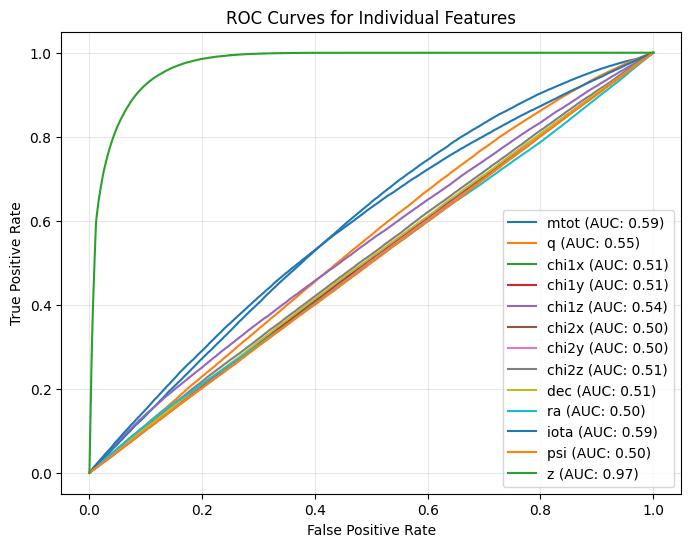

In [66]:
# Start with naive gaussian bayes classifier using single feature

gnb = GaussianNB()

auc_scores_gaus = []

features = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'ra', 'iota', 'psi', 'z']

# Roc for individual features
plt.figure(figsize=(8, 6))

for i in range(X_train.shape[1]):

    gnb.fit(X_train[:, i:i+1], y_train)

    y_prob = gnb.predict_proba(X_test[:, i:i+1])[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    auc_scores_gaus.append(auc_score)
    
    print(f"Single Feature used: {features[i]}, AUC: {auc_score:.3f}")
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{features[i]} (AUC: {auc_score:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Individual Features")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Single Feature used: mtot, AP Score: 0.179
Single Feature used: q, AP Score: 0.159
Single Feature used: chi1x, AP Score: 0.148
Single Feature used: chi1y, AP Score: 0.147
Single Feature used: chi1z, AP Score: 0.167
Single Feature used: chi2x, AP Score: 0.146
Single Feature used: chi2y, AP Score: 0.146
Single Feature used: chi2z, AP Score: 0.151
Single Feature used: dec, AP Score: 0.149
Single Feature used: ra, AP Score: 0.148
Single Feature used: iota, AP Score: 0.183
Single Feature used: psi, AP Score: 0.145
Single Feature used: z, AP Score: 0.843


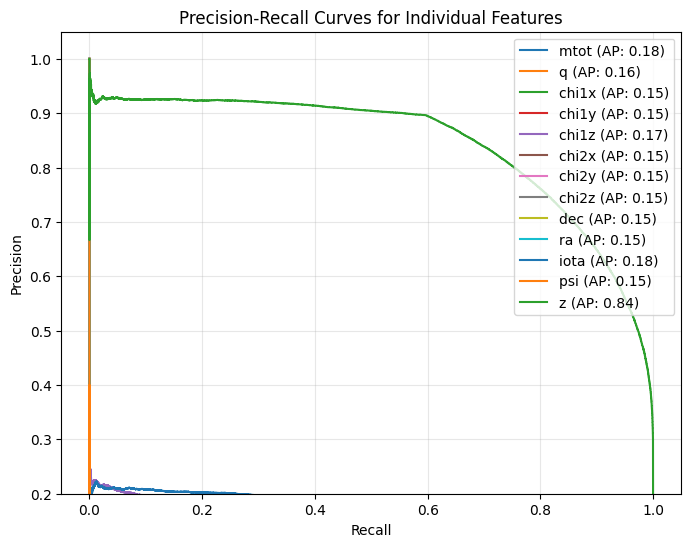

In [67]:
# Precision Recall curve for individual features
# since non_det>det is more accurate to evaluate classificator 

ap_scores_gaus = []

plt.figure(figsize=(8, 6))

for i in range(X_train.shape[1]):

    # Train on just one feature at a time
    gnb.fit(X_train[:, i:i+1], y_train)

    y_prob = gnb.predict_proba(X_test[:, i:i+1])[:, 1]
    
    # Area Under the PR Curve (Average Precision)
    ap_score = average_precision_score(y_test, y_prob)
    ap_scores_gaus.append(ap_score)
    
    print(f"Single Feature used: {features[i]}, AP Score: {ap_score:.3f}")
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    
    # Plot
    plt.plot( recall, precision, label=f"{features[i]} (AP: {ap_score:.2f})")

plt.ylabel("Precision")
plt.xlabel("Recall")
plt.ylim(0.2,1.05)
plt.title("Precision-Recall Curves for Individual Features")
plt.legend(loc='upper right') # Moved to lower left because PR curves usually start high on the left
plt.grid(alpha=0.3)
plt.show()

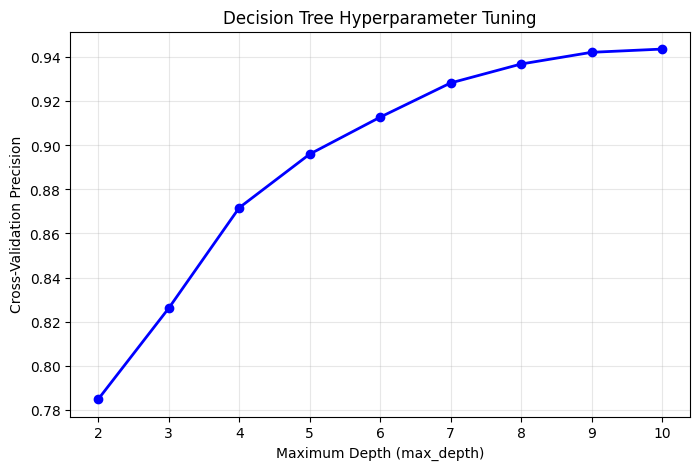

Best max_depth: 10
Best Mean Average Precision: 0.9437


In [ ]:
# Implement a decision tree classifier with cv to find best depth (use all feature togheter)

param_grid_dt = {'max_depth': range(2, 11)} 
dt = DecisionTreeClassifier(random_state=42)

# Grid search with 5-fold cross-validation to set the best depht
# We are optimizing for precision since the number of detectable samples is much smaller than the non-detectable 
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='average_precision', n_jobs=-1) 
grid_search_dt.fit(X_train, y_train)

val_scores_dt = grid_search_dt.cv_results_['mean_test_score']
depth_values = range(2, 11)





In [ ]:
# Plot Grid Search Results
plt.figure(figsize=(8, 5))
plt.plot(depth_values, val_scores_dt, marker='o', color='blue', lw=2)
plt.xlabel('Maximum Depth (max_depth)')
plt.ylabel('Cross-Validation Precision')
plt.title('Decision Tree Hyperparameter Tuning')
plt.xticks(depth_values)
plt.grid(alpha=0.3)
plt.show()

# Extract the best depth and its corresponding score
best_depth = grid_search_dt.best_params_['max_depth']
best_score_dt = grid_search_dt.best_score_
print(f'Best max_depth: {best_depth}')
print(f'Best Mean Average Precision: {best_score_dt:.4f}')

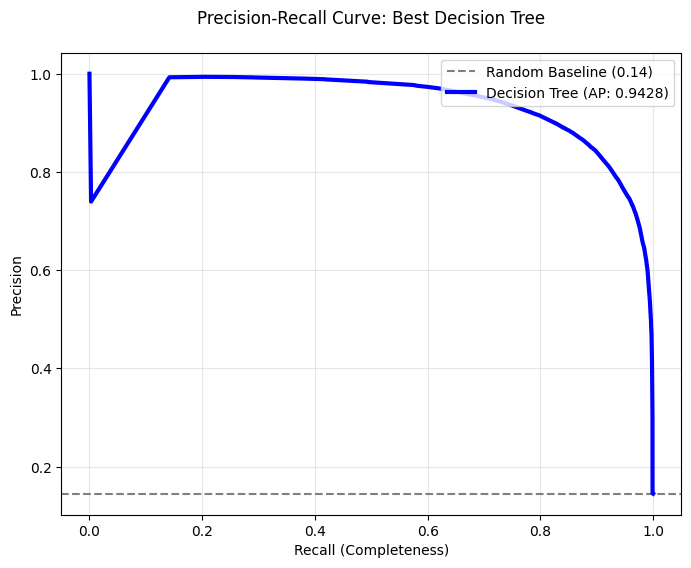

In [69]:
# Use the best model from the grid search to predict on the test set
best_dt_model = grid_search_dt.best_estimator_

# Get probabilities for the positive class
y_prob_dt = best_dt_model.predict_proba(X_test)[:, 1]
y_pred_dt = best_dt_model.predict(X_test)

# Calculate Average Precision and the curve points
ap_score_dt = average_precision_score(y_test, y_prob_dt)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))

# Plot Random Baseline
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')

# Plot Decision Tree Curve
plt.plot(recall_dt, precision_dt, color='Blue', lw=3, 
         label=f'Decision Tree (AP: {ap_score_dt:.4f})')

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')

plt.title(f'Precision-Recall Curve: Best Decision Tree\n')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

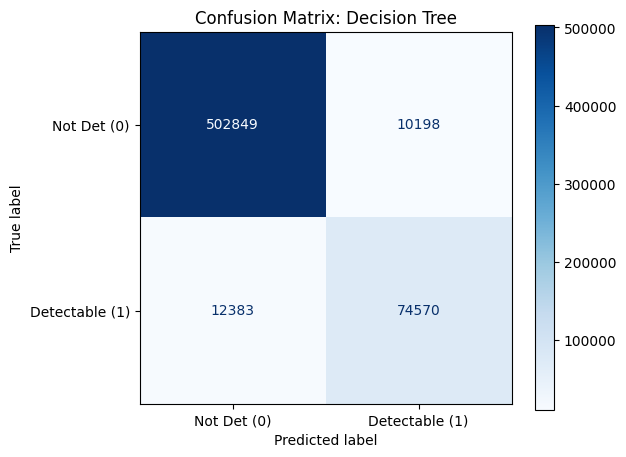

In [70]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Create the display object
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Confusion Matrix: Decision Tree')
plt.grid(False)
plt.show()

In [73]:
# Now add bagging to see if the performance improves

# Base decision tree with balanced weights
base_dt_for_bag = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Bagging
bagging_clf = BaggingClassifier(estimator=base_dt_for_bag, n_estimators=100, random_state=42, n_jobs=-1, max_samples=0.5)

param_grid_bag = {'estimator__max_depth': range(2, 11)} 

#CV
grid_search_bag = GridSearchCV(bagging_clf, param_grid_bag, cv=5, scoring='average_precision', verbose=1)
grid_search_bag.fit(X_train, y_train) 

val_scores_bag = grid_search_bag.cv_results_['mean_test_score']
depth_values = range(2, 11)


Fitting 3 folds for each of 5 candidates, totalling 15 fits


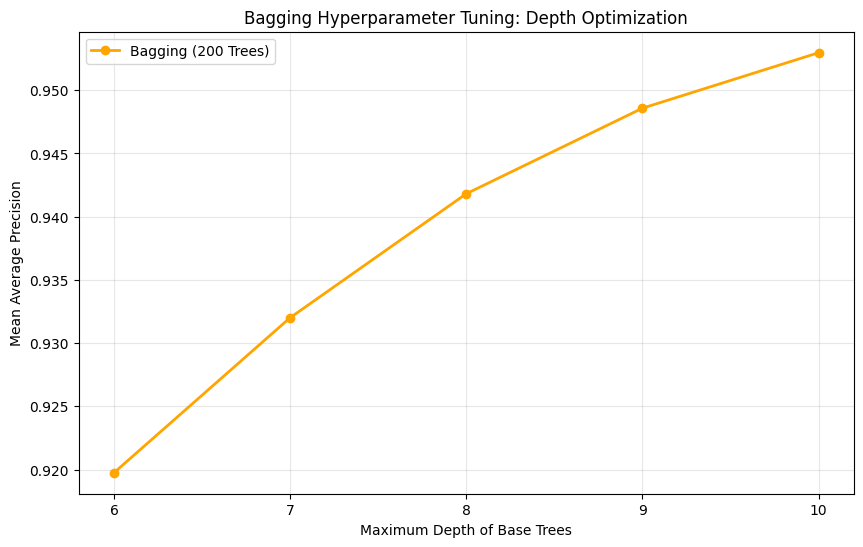

Best Parameters: {'estimator__max_depth': 10}
Best Average Precision: 0.9530


In [74]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(depth_values, val_scores_bag, marker='o', lw=2, color='Orange', label='Bagging (200 Trees)')

plt.xlabel('Maximum Depth of Base Trees')
plt.ylabel('Mean Average Precision')
plt.title('Bagging Hyperparameter Tuning: Depth Optimization')
plt.xticks(depth_values)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Results
best_params = grid_search_bag.best_params_
print(f"Best Parameters: {best_params}")
print(f"Best Average Precision: {grid_search_bag.best_score_:.4f}")

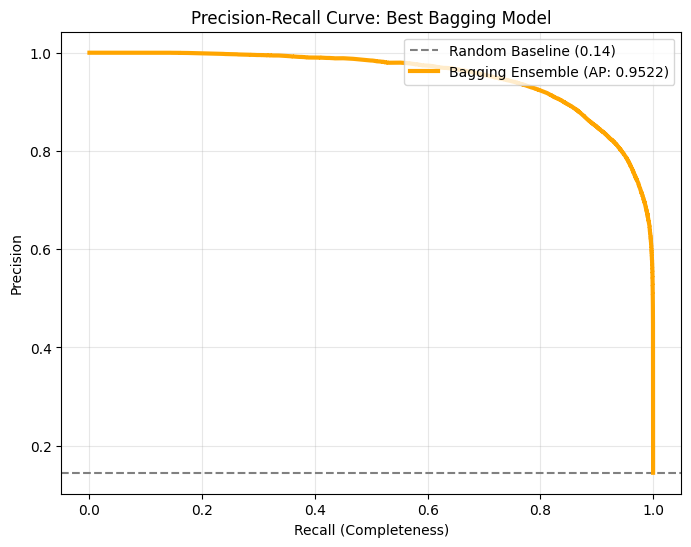

In [75]:
# Use the best model to plot Precision - Recall curve
best_bag_model = grid_search_bag.best_estimator_

y_prob_bag = best_bag_model.predict_proba(X_test)[:, 1]
y_pred_bag = best_bag_model.predict(X_test)

ap_score_bag = average_precision_score(y_test, y_prob_bag)
precision, recall, _ = precision_recall_curve(y_test, y_prob_bag)

# Plot
plt.figure(figsize=(8, 6))
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')

plt.plot(recall, precision, color='Orange', lw=3, 
         label=f'Bagging Ensemble (AP: {ap_score_bag:.4f})')

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve: Best Bagging Model')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()




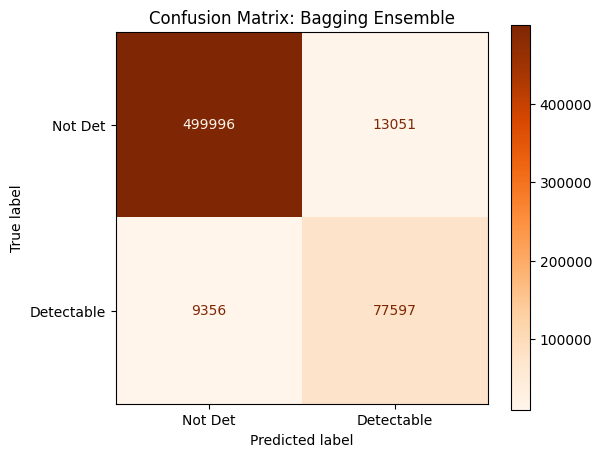

In [81]:
# Plot confusion matrix
custom_threshold = 0.8
cm = confusion_matrix(y_test, (y_prob_bag >= custom_threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Det", "Detectable"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Oranges', values_format='d', ax=ax)
plt.title('Confusion Matrix: Bagging Ensemble')
plt.grid(False)
plt.show()

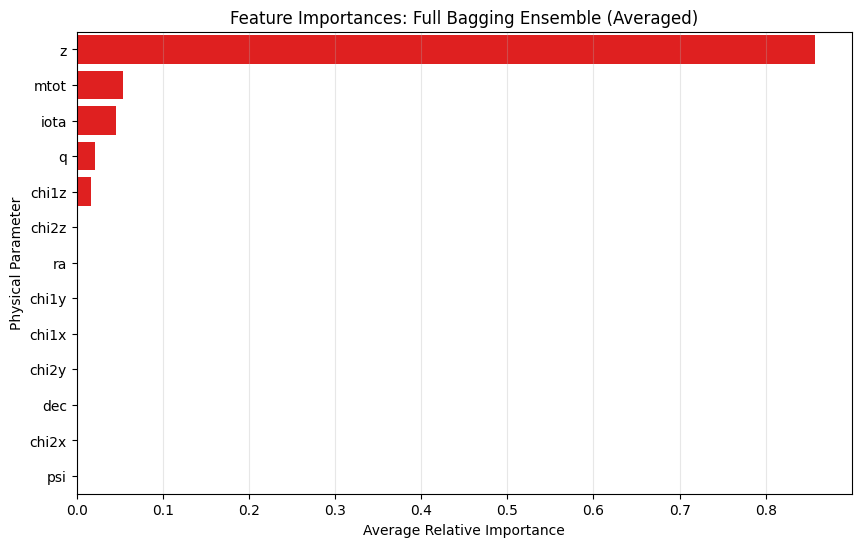

Top 5 important features according to Bagging:
   Feature  Importance
12       z    0.856867
0     mtot    0.054119
10    iota    0.046058
1        q    0.020988
4    chi1z    0.017020


In [77]:
# Plot the feature importance
bag_importances = np.mean([tree.feature_importances_ for tree in best_bag_model.estimators_], axis=0)

importance_df_bag = pd.DataFrame({
    'Feature': par_keys,
    'Importance': bag_importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_bag, x='Importance', y='Feature', color="red")
plt.title('Feature Importances: Full Bagging Ensemble (Averaged)')
plt.xlabel('Average Relative Importance')
plt.ylabel('Physical Parameter')
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Top 5 important features according to Bagging:")
print(importance_df_bag.head(5))

In [78]:
# Extract top 5 names and indices to see if using only them the value of AP score improves
top_5_features_bag_own = importance_df_bag.head(5)['Feature'].tolist()
top_5_indices_bag_own = [par_keys.index(f) for f in top_5_features_bag_own]

# Slice the training and testing sets
X_train_bag_final = X_train[:, top_5_indices_bag_own]
X_test_bag_final = X_test[:, top_5_indices_bag_own]

# Setup the Base Tree and Bagging Classifier
base_dt_final = DecisionTreeClassifier(class_weight='balanced', random_state=42)
bagging_final = BaggingClassifier(
    estimator=base_dt_final, 
    n_estimators=100, 
    random_state=42,
    max_samples= 0.5, 
    n_jobs=-1
)

# Setup GridSearchCV for the new Top 5
param_grid_bag_final = {'estimator__max_depth': range(2, 11)}

grid_search_bag_final = GridSearchCV(
    bagging_final, 
    param_grid_bag_final, 
    cv=5, 
    scoring='average_precision',
    n_jobs=-1
)
grid_search_bag_final.fit(X_train_bag_final, y_train)

# Extract best results
best_depth_bag_final = grid_search_bag_final.best_params_['estimator__max_depth']
best_score_bag_final = grid_search_bag_final.best_score_
print(f"Final Bagging Top 5 Best max_depth: {best_depth_bag_final}")
print(f"Final Bagging Top 5 CV Average Precision: {best_score_bag_final:.4f}")

Final Bagging Top 5 Best max_depth: 10
Final Bagging Top 5 CV Average Precision: 0.9531


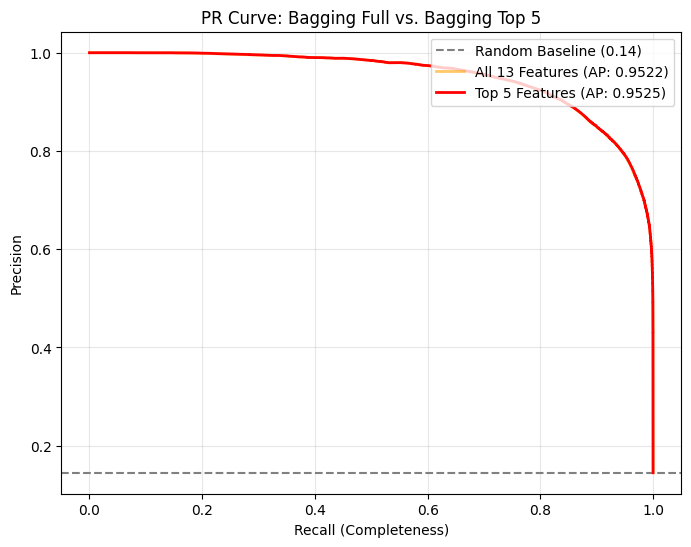

In [79]:
best_bag_final_model = grid_search_bag_final.best_estimator_

y_prob_bag_final = best_bag_final_model.predict_proba(X_test_bag_final)[:, 1]
#y_pred_bag_final = best_bag_final_model.predict(X_test_bag_final)

ap_score_bag_final = average_precision_score(y_test, y_prob_bag_final)
precision_bag_f, recall_bag_f, _ = precision_recall_curve(y_test, y_prob_bag_final)

# Plot Precision-Recall curve comparison
plt.figure(figsize=(8, 6))
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')
plt.plot(recall, precision, label=f'All 13 Features (AP: {ap_score_bag:.4f})', color='orange', alpha=0.6, lw=2)
plt.plot(recall_bag_f, precision_bag_f, label=f'Top 5 Features (AP: {ap_score_bag_final:.4f})', color='red', lw=2)

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')
plt.title('PR Curve: Bagging Full vs. Bagging Top 5')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

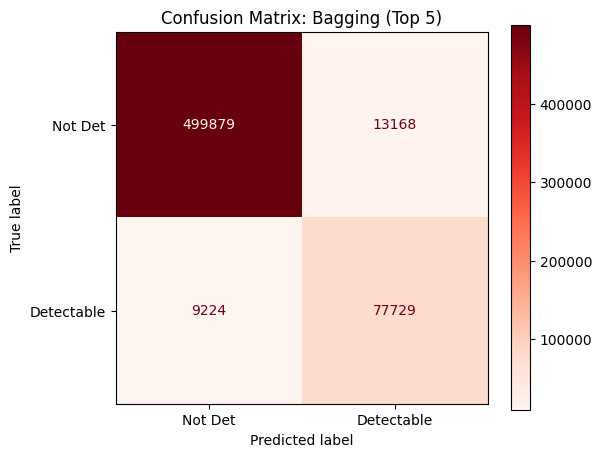

In [82]:
# Confusion matrix
cm_bag_final = confusion_matrix(y_test, (y_prob_bag_final >= custom_threshold).astype(int)) 
disp_bag_final = ConfusionMatrixDisplay(confusion_matrix=cm_bag_final, display_labels=["Not Det", "Detectable"])

fig, ax = plt.subplots(figsize=(6, 5))
disp_bag_final.plot(cmap='Reds', values_format='d', ax=ax)
plt.title(f'Confusion Matrix: Bagging (Top 5)')
plt.grid(False)
plt.show()

In [83]:
# Now use Random forest classifier
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# hyperparameters
param_grid_rf = { 'max_depth': range (1,11), 'n_estimators': [100], 'min_samples_leaf': [10]}

grid_search_rf = GridSearchCV(rf_clf, param_grid_rf, cv=5, scoring='average_precision', verbose=1)
grid_search_rf.fit(X_train, y_train)


results_rf = grid_search_rf.cv_results_
best_params_rf = grid_search_rf.best_params_
best_rf_model = grid_search_rf.best_estimator_

print(f"Best Parameters: {best_params_rf}")
print(f"Best Mean Average Precision: {grid_search_rf.best_score_:.4f}")




Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 100}
Best Mean Average Precision: 0.9447


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


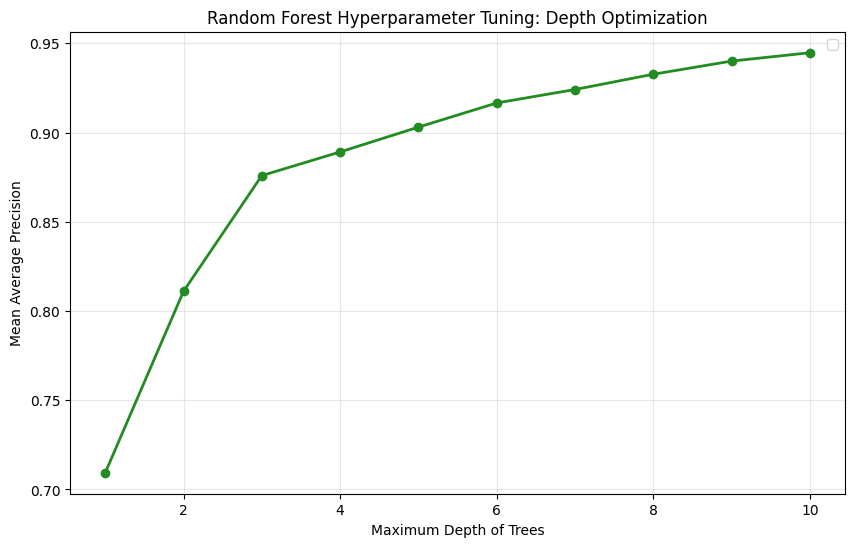

In [84]:
scores = results_rf['mean_test_score']
depths = list(range(1, 11))

plt.figure(figsize=(10, 6))
plt.plot(depths, scores, marker='o', lw=2, color='forestgreen')

plt.xlabel('Maximum Depth of Trees')
plt.ylabel('Mean Average Precision')
plt.title('Random Forest Hyperparameter Tuning: Depth Optimization')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

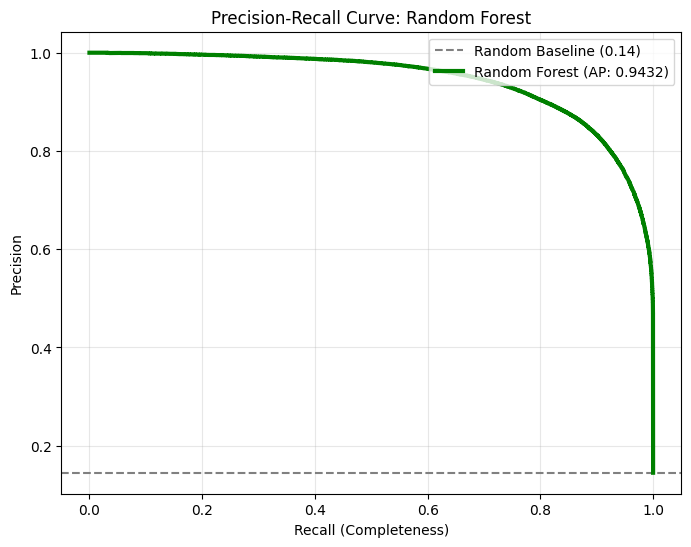

In [85]:
# Best model Precision Recall
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf_model.predict(X_test)

ap_score_rf = average_precision_score(y_test, y_prob_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

# Plot Precision Recall curve
plt.figure(figsize=(8, 6))
baseline = np.sum(y_test == 1) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Random Baseline ({baseline:.2f})')

plt.plot(recall_rf, precision_rf, color='green', lw=3, 
         label=f'Random Forest (AP: {ap_score_rf:.4f})')

plt.xlabel('Recall (Completeness)')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve: Random Forest')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()



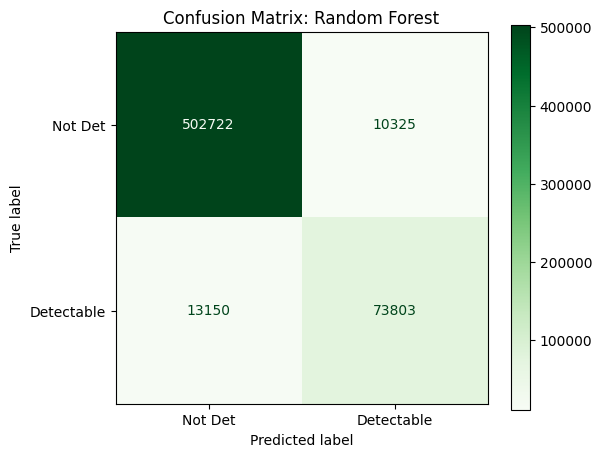

In [86]:
# Plot confusion matrix
cm_rf = confusion_matrix(y_test, (y_prob_rf >= custom_threshold).astype(int))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Not Det", "Detectable"])

fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(cmap='Greens', values_format='d', ax=ax)
plt.title('Confusion Matrix: Random Forest')
plt.grid(False)
plt.show()


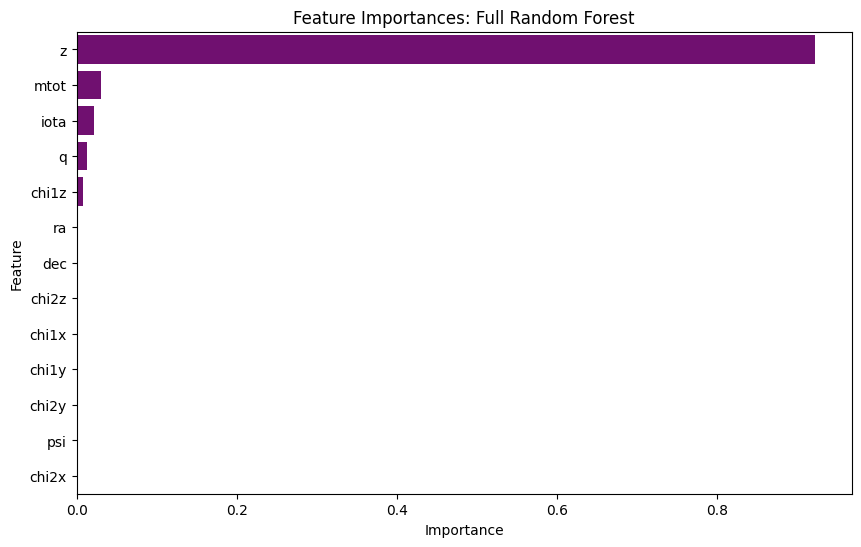

In [87]:
# Use the feature importances from the best_rf_model we just trained
importance_df_rf = pd.DataFrame({
    'Feature': par_keys,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_rf, x='Importance', y='Feature', color='purple' )
plt.title('Feature Importances: Full Random Forest')
plt.show()

# Extract top 5 names
top_5_features = importance_df_rf.head(5)['Feature'].tolist()
top_5_indices = [par_keys.index(f) for f in top_5_features]

# Slice the training and testing sets
X_train_top5 = X_train[:, top_5_indices]
X_test_top5 = X_test[:, top_5_indices]

In [88]:
# Initialize new Random Forest using only best 5 features
rf_top5_clf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Define a focused Grid Search
param_grid_top5 = {
    'max_depth': range(1,11),
    'n_estimators': [100],
    'min_samples_leaf': [10] 
}

# Execute CV
grid_search_top5 = GridSearchCV(
    rf_top5_clf, 
    param_grid_top5, 
    cv=5, 
    scoring='average_precision', 
    verbose=1
)

grid_search_top5.fit(X_train_top5, y_train)

# Extract Best Model
best_rf_top5 = grid_search_top5.best_estimator_
best_params_top5 = grid_search_top5.best_params_

print(f"\nBest Params (Top 5): {best_params_top5}")
print(f"CV Average Precision: {grid_search_top5.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Params (Top 5): {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 100}
CV Average Precision: 0.9562


In [ ]:
# Filter the data
X_train_top5 = X_train[:, top_5_indices]
X_test_top5 = X_test[:, top_5_indices]

y_prob_top5 = best_rf_top5.predict_proba(X_test_top5)[:, 1]
y_pred_top5 = best_rf_top5.predict(X_test_top5)

ap_score_top5 = average_precision_score(y_test, y_prob_top5)
precision_top5, recall_top5, _ = precision_recall_curve(y_test, y_prob_top5)



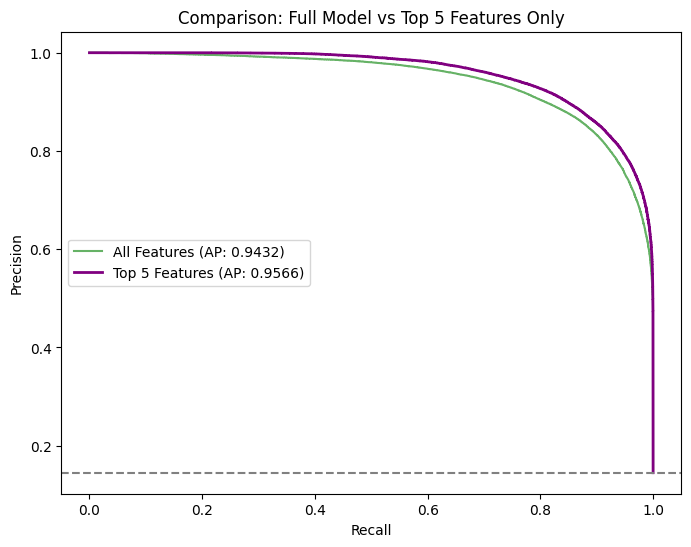

In [90]:
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label=f'All Features (AP: {ap_score_rf:.4f})', color='green', alpha=0.6)
plt.plot(recall_top5, precision_top5, label=f'Top 5 Features (AP: {ap_score_top5:.4f})', color='purple', lw=2)
plt.axhline(y=baseline, color='gray', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparison: Full Model vs Top 5 Features Only')
plt.legend()
plt.show()

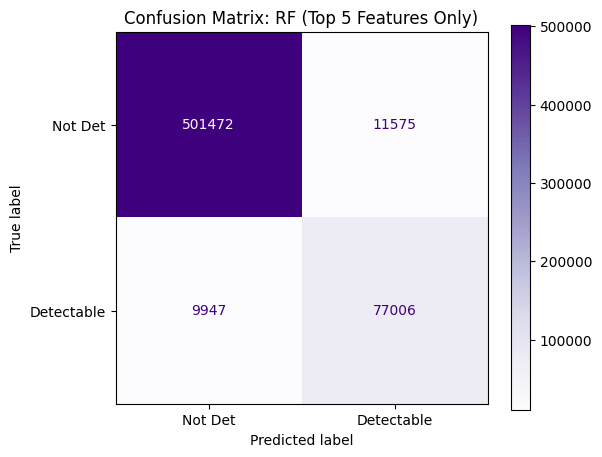

In [95]:
custom_threshold=0.8
cm_t5 = confusion_matrix(y_test, (y_prob_top5 >= custom_threshold).astype(int))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_t5, display_labels=["Not Det", "Detectable"]).plot(cmap='Purples', values_format='d', ax=ax)
plt.title('Confusion Matrix: RF (Top 5 Features Only)')
plt.grid(False)
plt.show()